In [3]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [4]:
df=pd.read_csv("messy.csv")
df

,customer_id,age,income,city,device,spending_score,experience
0,101,25,30000.0,Chennai,Mobile,40.0,2
1,102,NaN,45000.0,Delhi,Laptop,60.0,3
2,103,35,50000.0,Mumbai,Mobile,NaN,5
3,104,22,20000.0,Chennai,Tablet,30.0,1
4,105,27,35000.0,Bangalore,Mobile,50.0,2
5,106,thirty,70000.0,Delhi,Laptop,80.0,7
6,107,45,120000.0,Mumbai,Laptop,95.0,20
7,108,21,18000.0,Chennai,Mobile,20.0,0
8,109,29,40000.0,Bangalore,Tablet,55.0,4
9,110,31,42000.0,Delhi,Mobile,60.0,6


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     20 non-null     int64  
 1   age             18 non-null     str    
 2   income          19 non-null     float64
 3   city            20 non-null     str    
 4   device          20 non-null     str    
 5   spending_score  19 non-null     float64
 6   experience      20 non-null     int64  
dtypes: float64(2), int64(2), str(3)
memory usage: 1.2 KB


In [6]:
df.isnull().sum()

customer_id       0
age               2
income            1
city              0
device            0
spending_score    1
experience        0
dtype: int64

In [7]:
df["age"]=pd.to_numeric(df["age"],errors="coerce")
# df=df[df[df["age"]>0]]

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     20 non-null     int64  
 1   age             17 non-null     float64
 2   income          19 non-null     float64
 3   city            20 non-null     str    
 4   device          20 non-null     str    
 5   spending_score  19 non-null     float64
 6   experience      20 non-null     int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 1.2 KB


In [9]:
df["age"]=df["age"].fillna(df["age"].mean())
df["income"]=df["income"].fillna(df["income"].median())
df["spending_score"]=df["spending_score"].fillna(df["spending_score"].median())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   customer_id     20 non-null     int64  
 1   age             20 non-null     float64
 2   income          20 non-null     float64
 3   city            20 non-null     str    
 4   device          20 non-null     str    
 5   spending_score  20 non-null     float64
 6   experience      20 non-null     int64  
dtypes: float64(3), int64(2), str(2)
memory usage: 1.2 KB


In [10]:
df.isnull().sum()

customer_id       0
age               0
income            0
city              0
device            0
spending_score    0
experience        0
dtype: int64

In [11]:
df

,customer_id,age,income,city,device,spending_score,experience
0,101,25.000000,30000.0,Chennai,Mobile,40.0,2
1,102,30.588235,45000.0,Delhi,Laptop,60.0,3
2,103,35.000000,50000.0,Mumbai,Mobile,55.0,5
3,104,22.000000,20000.0,Chennai,Tablet,30.0,1
4,105,27.000000,35000.0,Bangalore,Mobile,50.0,2
5,106,30.588235,70000.0,Delhi,Laptop,80.0,7
6,107,45.000000,120000.0,Mumbai,Laptop,95.0,20
7,108,21.000000,18000.0,Chennai,Mobile,20.0,0
8,109,29.000000,40000.0,Bangalore,Tablet,55.0,4
9,110,31.000000,42000.0,Delhi,Mobile,60.0,6


In [12]:
Q1=df["income"].quantile(0.25)
Q3=df["income"].quantile(0.75)
IQR=Q3-Q1
lower = Q1- 1.5*IQR
upper = Q3 + 1.5*IQR
df=df[(df["income"]>=lower)& (df["income"]<=upper)]

In [13]:
df

,customer_id,age,income,city,device,spending_score,experience
0,101,25.000000,30000.0,Chennai,Mobile,40.0,2
1,102,30.588235,45000.0,Delhi,Laptop,60.0,3
2,103,35.000000,50000.0,Mumbai,Mobile,55.0,5
3,104,22.000000,20000.0,Chennai,Tablet,30.0,1
4,105,27.000000,35000.0,Bangalore,Mobile,50.0,2
5,106,30.588235,70000.0,Delhi,Laptop,80.0,7
7,108,21.000000,18000.0,Chennai,Mobile,20.0,0
8,109,29.000000,40000.0,Bangalore,Tablet,55.0,4
9,110,31.000000,42000.0,Delhi,Mobile,60.0,6
10,111,30.588235,39000.0,Chennai,Mobile,50.0,3


In [14]:
df=df.drop("customer_id",axis=1)
df

,age,income,city,device,spending_score,experience
0,25.000000,30000.0,Chennai,Mobile,40.0,2
1,30.588235,45000.0,Delhi,Laptop,60.0,3
2,35.000000,50000.0,Mumbai,Mobile,55.0,5
3,22.000000,20000.0,Chennai,Tablet,30.0,1
4,27.000000,35000.0,Bangalore,Mobile,50.0,2
5,30.588235,70000.0,Delhi,Laptop,80.0,7
7,21.000000,18000.0,Chennai,Mobile,20.0,0
8,29.000000,40000.0,Bangalore,Tablet,55.0,4
9,31.000000,42000.0,Delhi,Mobile,60.0,6
10,30.588235,39000.0,Chennai,Mobile,50.0,3


In [15]:
df=df.drop_duplicates()
df

,age,income,city,device,spending_score,experience
0,25.000000,30000.0,Chennai,Mobile,40.0,2
1,30.588235,45000.0,Delhi,Laptop,60.0,3
2,35.000000,50000.0,Mumbai,Mobile,55.0,5
3,22.000000,20000.0,Chennai,Tablet,30.0,1
4,27.000000,35000.0,Bangalore,Mobile,50.0,2
5,30.588235,70000.0,Delhi,Laptop,80.0,7
7,21.000000,18000.0,Chennai,Mobile,20.0,0
8,29.000000,40000.0,Bangalore,Tablet,55.0,4
9,31.000000,42000.0,Delhi,Mobile,60.0,6
10,30.588235,39000.0,Chennai,Mobile,50.0,3


In [16]:
df["age"]=df["age"].astype(int)
df["spending_score"]=df["spending_score"].astype(int)

In [17]:
df=pd.get_dummies(df,columns=["city","device"])


In [18]:
df

,age,income,spending_score,experience,city_Bangalore,city_Chennai,city_Delhi,city_Mumbai,device_Laptop,device_Mobile,device_Tablet
0,25,30000.0,40,2,False,True,False,False,False,True,False
1,30,45000.0,60,3,False,False,True,False,True,False,False
2,35,50000.0,55,5,False,False,False,True,False,True,False
3,22,20000.0,30,1,False,True,False,False,False,False,True
4,27,35000.0,50,2,True,False,False,False,False,True,False
5,30,70000.0,80,7,False,False,True,False,True,False,False
7,21,18000.0,20,0,False,True,False,False,False,True,False
8,29,40000.0,55,4,True,False,False,False,False,False,True
9,31,42000.0,60,6,False,False,True,False,False,True,False
10,30,39000.0,50,3,False,True,False,False,False,True,False


In [19]:
scaler=StandardScaler()
x_scaled=scaler.fit_transform(df)
# x_scaled=df

In [20]:
x_scaled

array([[-0.74980638, -0.70361666, -0.79603867, -0.75796071, -0.5547002 ,
         1.54919334, -0.64549722, -0.46291005, -0.46291005,  0.83666003,
        -0.5547002 ],
       [ 0.21585335,  0.40392808,  0.35567685, -0.44368432, -0.5547002 ,
        -0.64549722,  1.54919334, -0.46291005,  2.1602469 , -1.19522861,
        -0.5547002 ],
       [ 1.18151308,  0.77310966,  0.06774797,  0.18486847, -0.5547002 ,
        -0.64549722, -0.64549722,  2.1602469 , -0.46291005,  0.83666003,
        -0.5547002 ],
       [-1.32920221, -1.44197982, -1.37189643, -1.07223711, -0.5547002 ,
         1.54919334, -0.64549722, -0.46291005, -0.46291005, -1.19522861,
         1.80277564],
       [-0.36354249, -0.33443508, -0.22018091, -0.75796071,  1.80277564,
        -0.64549722, -0.64549722, -0.46291005, -0.46291005,  0.83666003,
        -0.5547002 ],
       [ 0.21585335,  2.24983598,  1.50739238,  0.81342125, -0.5547002 ,
        -0.64549722,  1.54919334, -0.46291005,  2.1602469 , -1.19522861,
        -0.554

In [21]:
pca=PCA(n_components=2)
pca_scaled=pca.fit_transform(x_scaled)

In [22]:
pca_scaled

array([[-2.10165016, -0.71776277],
       [ 1.56579641, -2.1111235 ],
       [ 0.4542349 ,  0.46106773],
       [-3.02020338,  0.22379919],
       [-0.60759126,  1.0430324 ],
       [ 3.39965931, -1.81111093],
       [-3.56680812, -1.03613863],
       [ 0.1088467 ,  2.38073364],
       [ 1.16095028, -0.79600847],
       [-1.0452018 , -0.45482738],
       [-2.0687831 ,  0.977084  ],
       [ 1.64023264, -2.0489181 ],
       [ 1.55378801,  1.66337621],
       [-1.73536247, -0.60945042],
       [-1.96847303, -0.17735268],
       [ 2.3141394 ,  3.0352525 ],
       [ 3.91642567, -0.02165278]])

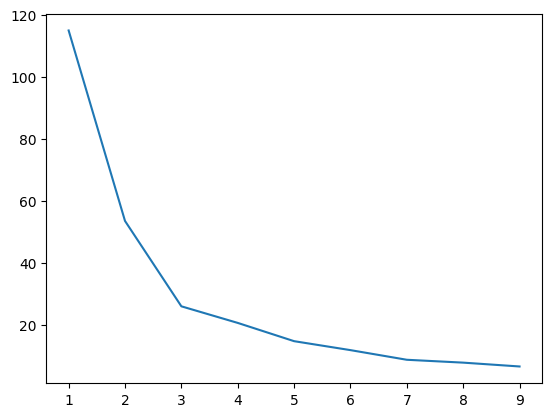

In [23]:
inertia=[]
for k in range(1,10):
    model=KMeans(n_clusters=k)
    model.fit(pca_scaled)
    inertia.append(model.inertia_)

plt.plot(range(1,10),inertia)
plt.show()

    

In [24]:
model = KMeans(n_clusters=3)
clusters=model.fit_predict(pca_scaled)
# model = KMeans(n_clusters=3)
# clusters=model.fit_predict(x_scaled)
# clusters

In [25]:
df["cluster"]=clusters

In [26]:
df

,age,income,spending_score,experience,city_Bangalore,city_Chennai,city_Delhi,city_Mumbai,device_Laptop,device_Mobile,device_Tablet,cluster
0,25,30000.0,40,2,False,True,False,False,False,True,False,0
1,30,45000.0,60,3,False,False,True,False,True,False,False,2
2,35,50000.0,55,5,False,False,False,True,False,True,False,1
3,22,20000.0,30,1,False,True,False,False,False,False,True,0
4,27,35000.0,50,2,True,False,False,False,False,True,False,1
5,30,70000.0,80,7,False,False,True,False,True,False,False,2
7,21,18000.0,20,0,False,True,False,False,False,True,False,0
8,29,40000.0,55,4,True,False,False,False,False,False,True,1
9,31,42000.0,60,6,False,False,True,False,False,True,False,2
10,30,39000.0,50,3,False,True,False,False,False,True,False,0


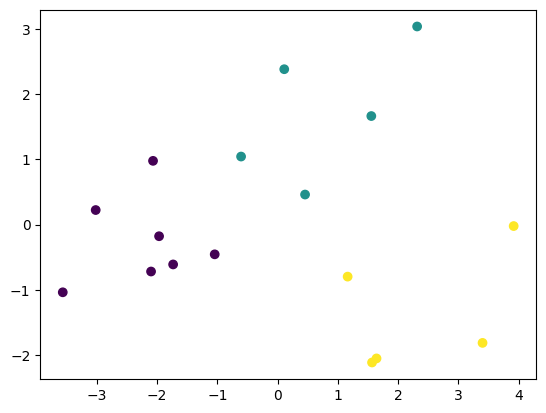

In [34]:
# # plt.scatter(pca_scaled[:0],pca_scaled[:1],c=clusters)
plt.scatter(pca_scaled[:,0], pca_scaled[:,1], c=clusters)
# # plt.scatter(df["income"],df["spending_score"],c=clusters)
# # plt.xlabel("income")
# # plt.ylabel("spending_score")

plt.show()


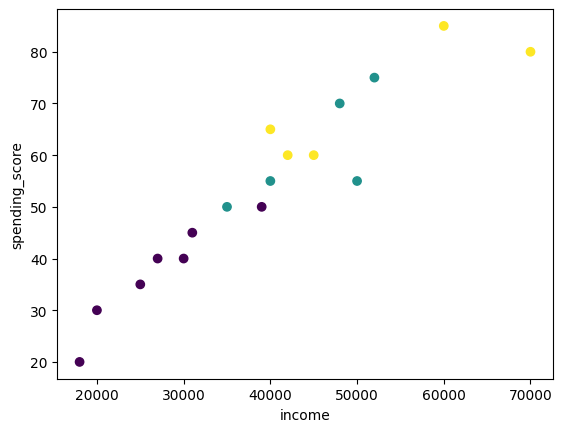

In [31]:
plt.scatter(df["income"],df["spending_score"],c=clusters)
plt.xlabel("income")
plt.ylabel("spending_score")

plt.show()

In [29]:
from sklearn.metrics import silhouette_score

for k in range(2, 7):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(pca_scaled)
    
    score = silhouette_score(pca_scaled, labels)
    print(f"k={k}, silhouette={score}")

k=2, silhouette=0.4324850944877496
k=3, silhouette=0.4904623979376307
k=4, silhouette=0.3418046843260031
k=5, silhouette=0.28860774674689404
k=6, silhouette=0.3053110730156857
